# Barra_frets — monthly Barra factor WLS

Lazy cross-sectional weighted least squares of `ret` on Barra style + industry
exposures, one regression per `date` (month).

**Input:** `./parquet_files/fexp_panel.parquet` (from `fexp_panel2_parquet.ipynb`)  
**Output:** monthly betas (+ optional fit statistics)  
**Script:** `barra_frets.py` — same logic, runnable from the CLI

- Weight: `regwt = 1 / srisk²`
- No intercept (`WORLD` ≡ 1 for all names)
- `country_gem4 == "USA"` filter is a pushdown placeholder on the lazy scan

**Performance:** Fit statistics (`sse`, `tss`, `r2`) are **off by default** (`INCLUDE_STATS = False`).
Enabling them runs a second WLS pass per month (residuals) and roughly doubles regression time.

**Kernel:** select **`plfrets (.venv)`** in the kernel picker. The main WLS `collect()` cell takes ~10s.
Run the connectivity cell first if the kernel was recently restarted.

In [14]:
# Connectivity check — should print immediately after kernel start
import sys
print(sys.executable)
print("kernel ok")

c:\Users\algertp\cursorprojects\plfrets\.venv\Scripts\python.exe
kernel ok


In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import polars_ols  # noqa: F401 — registers .least_squares namespace

PARQUET_PATH = Path("parquet_files/fexp_panel.parquet")
OUTPUT_PATH = Path("parquet_files/fexp_wls_betas.parquet")
UNIVARIATE_OUTPUT_PATH = Path("parquet_files/fexp_wls_univariate_betas.parquet")

INCLUDE_STATS = False  # set True for sse / tss / r2 (slower: second WLS pass per month)
TRAIL_MONTHS = 36  # trailing 3-year window for plot

RISK_FACTORS = [
    "WORLD", "BETA", "BTOP", "DIVYILD", "EARNQLTY", "EARNVAR", "EARNYILD",
    "GROWTH", "INVSQLTY", "LEVERAGE", "LIQUIDTY", "LTREVRSL", "MIDCAP",
    "MOMENTUM", "PROFIT", "RESVOL", "SIZE",
]

INDUSTRY_FACTORS = [
    "AEROSPCE", "AIRLINES", "DIVMETAL", "AUTOCOMP", "BANKS", "BIOTECH",
    "BLDCNSTR", "CHEMICAL", "COMMSVCS", "COMMUNIC", "COMPUTER", "CONSTPP",
    "CONSDUR", "CONSVCS", "DIVFIN", "ENERGY", "AGROCHEM", "FOODPRD", "FOODRETL",
    "GOLD", "HLTHEQP", "HLTHSVC", "HSHLDPRD", "INOILGAS", "INSURNCE", "INTERNET",
    "SOFTWARE", "MACHINRY", "MEDIA", "OILGAS", "OILEXPL", "PHARMA", "PRECMETL",
    "REALEST", "RETAIL", "SEMICOND", "SMICNDEQ", "STEEL", "TELECOM", "TRNSPORT",
    "UTILITY", "CAPMRKTS", "RGNLBNKS", "THRIFTS", "RLESTMNG",
]

PLOT_FACTORS = ["MOMENTUM", "BETA", "RESVOL", "SIZE", "EARNYILD"]

SUMMARY_FACTORS = [
    "BETA", "WORLD", "GROWTH", "EARNYILD",
    "MOMENTUM", "SIZE", "PROFIT", "RESVOL",
]

FACTOR_COLUMNS = RISK_FACTORS + INDUSTRY_FACTORS
print(f"{len(RISK_FACTORS)} style + {len(INDUSTRY_FACTORS)} industry = {len(FACTOR_COLUMNS)} factors")

17 style + 45 industry = 62 factors


In [16]:
SHOW_PLAN = False  # True prints a large query plan and can freeze the notebook UI

def wls_expr(features: list[str], mode: str, *, add_intercept: bool = False) -> pl.Expr:
    return pl.col("ret").least_squares.wls(
        *[pl.col(name) for name in features],
        sample_weights=pl.col("regwt"),
        add_intercept=add_intercept,
        null_policy="drop",
        solve_method="svd",
        mode=mode,
    )


weighted_mean_ret = (pl.col("ret") * pl.col("regwt")).sum() / pl.col("regwt").sum()

agg_exprs: list[pl.Expr] = [
    pl.len().alias("n_obs"),
    wls_expr(FACTOR_COLUMNS, "coefficients").alias("betas"),
]
if INCLUDE_STATS:
    agg_exprs.extend(
        [
            (pl.col("regwt") * wls_expr(FACTOR_COLUMNS, "residuals").pow(2)).sum().alias("sse"),
            (pl.col("regwt") * (pl.col("ret") - weighted_mean_ret).pow(2)).sum().alias("tss"),
        ]
    )

lazy_plan = (
    pl.scan_parquet(PARQUET_PATH)
    .filter(pl.col("country_gem4") == "USA")  # pushdown placeholder
    .with_columns((1.0 / pl.col("srisk").pow(2)).alias("regwt"))
    .group_by("date")
    .agg(*agg_exprs)
    .sort("date")
)
if INCLUDE_STATS:
    lazy_plan = lazy_plan.with_columns((1.0 - pl.col("sse") / pl.col("tss")).alias("r2"))

if SHOW_PLAN:
    print(lazy_plan.explain(optimized=True))
else:
    print("lazy plan ready (set SHOW_PLAN=True to inspect)")

lazy plan ready (set SHOW_PLAN=True to inspect)


In [17]:
results_df = lazy_plan.collect()

monthly_betas = results_df.unnest("betas").sort("date")
print(f"{monthly_betas.height:,} months × {len(FACTOR_COLUMNS)} betas")

preview_cols = ["date", "n_obs", "BETA", "EARNYILD"]
if INCLUDE_STATS:
    preview_cols.extend(["sse", "tss", "r2"])
monthly_betas.select(preview_cols).head(5)

379 months × 62 betas


date,n_obs,BETA,EARNYILD
date,u32,f64,f64
1994-12-31,4390,-0.001753,0.004564
1995-01-31,4373,0.012295,0.005709
1995-02-28,4361,0.000255,-0.00111
1995-03-31,4451,-0.000803,0.002861
1995-04-30,4439,0.001672,0.004857


In [18]:
monthly_betas.write_parquet(OUTPUT_PATH)
print(f"Wrote {OUTPUT_PATH.resolve()}")

Wrote C:\Users\algertp\cursorprojects\plfrets\parquet_files\fexp_wls_betas.parquet


## Univariate risk-factor WLS (industry-controlled)

For each style factor, run a separate monthly cross-sectional WLS:

`ret ~ risk_factor + industries` with `regwt = 1 / srisk²`, no intercept.

Only the target risk-factor beta is retained from each regression. All 17
regressions share one lazy plan (single scan + `group_by`), so runtime is ~2–3×
the multivariate pass, not ~17×. Output:
`./parquet_files/fexp_wls_univariate_betas.parquet`.

In [ ]:
def univariate_risk_beta_expr(risk_factor: str) -> pl.Expr:
    features = [risk_factor, *INDUSTRY_FACTORS]
    return (
        wls_expr(features, "coefficients")
        .struct.field(risk_factor)
        .alias(risk_factor)
    )


univariate_lazy_plan = (
    pl.scan_parquet(PARQUET_PATH)
    .filter(pl.col("country_gem4") == "USA")
    .with_columns((1.0 / pl.col("srisk").pow(2)).alias("regwt"))
    .group_by("date")
    .agg(
        pl.len().alias("n_obs"),
        *[univariate_risk_beta_expr(factor) for factor in RISK_FACTORS],
    )
    .sort("date")
)

univariate_betas = univariate_lazy_plan.collect()
print(f"{univariate_betas.height:,} months × {len(RISK_FACTORS)} industry-controlled betas")
univariate_betas.select(["date", "n_obs", "MOMENTUM", "BETA", "EARNYILD"]).head(5)

In [ ]:
univariate_betas.write_parquet(UNIVARIATE_OUTPUT_PATH)
print(f"Wrote {UNIVARIATE_OUTPUT_PATH.resolve()}")

## Selected factor summary

Mean and Sharpe (`sqrt(12) × mean / stdev`) for a subset of style factors,
using industry-controlled univariate WLS betas from Phase 3.

In [19]:
factor_summary = (
    univariate_betas.select(SUMMARY_FACTORS)
    .unpivot(on=SUMMARY_FACTORS, variable_name="factor", value_name="beta")
    .group_by("factor")
    .agg(
        pl.col("beta").mean().alias("mean"),
        (pl.col("beta").mean() / pl.col("beta").std() * (12**0.5)).alias("sharpe"),
    )
    .with_columns(
        pl.col("mean").round(6),
        pl.col("sharpe").round(3),
    )
    .sort(
        pl.col("factor").replace_strict(
            {name: idx for idx, name in enumerate(SUMMARY_FACTORS)},
            default=len(SUMMARY_FACTORS),
        )
    )
)
factor_summary

factor,mean,sharpe
str,f64,f64
"""BETA""",0.000476,0.102
"""WORLD""",0.006888,0.528
"""GROWTH""",0.000558,0.492
"""EARNYILD""",0.001409,0.695
"""MOMENTUM""",0.001827,0.443
"""SIZE""",-0.000666,-0.289
"""PROFIT""",0.000766,0.608
"""RESVOL""",-0.000929,-0.32


## Trailing 3-year factor returns

Rolling `TRAIL_MONTHS`-month average of monthly industry-controlled univariate
WLS factor returns (betas), subset to `PLOT_FACTORS`.

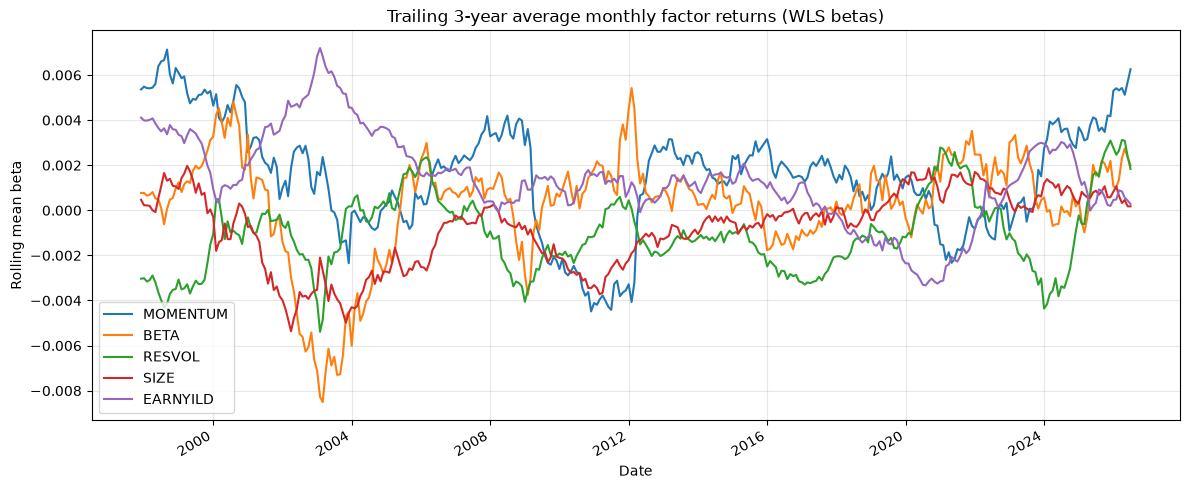

In [ ]:
trailing = univariate_betas.sort("date").select(
    "date",
    *[
        pl.col(f).rolling_mean(window_size=TRAIL_MONTHS, min_samples=TRAIL_MONTHS).alias(f)
        for f in PLOT_FACTORS
    ],
)

fig, ax = plt.subplots(figsize=(12, 5))
dates = trailing["date"].to_list()
for factor in PLOT_FACTORS:
    ax.plot(dates, trailing[factor], label=factor, linewidth=1.5)
ax.set_title(
    f"Trailing {TRAIL_MONTHS // 12}-year average monthly factor returns "
    "(industry-controlled WLS betas)"
)
ax.set_xlabel("Date")
ax.set_ylabel("Rolling mean beta")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()